# Impact Analysis
##### - How Data Drift Degrades Fraud Detection Performance -
---
Students:
- Levente Staub (243756)
- Gergő Honyák (242720)
- Máté Kovásznai (241960)
---
## Overview
To run the notebook make sure the dependencies are downloaded and the **MODEL_PATH** variable helds the correct path for the baseline model.
In this notebook we ask the key MLOps question:

**When the real world changes, how badly does our model break?**

We will:
1. **Reload the trained model** (no retraining, same weights as production)
2. **Evaluate it on each of the 5 drift batches** (drift_1 → drift_5)
3. **Track F1, AUC-ROC, Precision, and Recall per batch**
4. **Summarise findings** with actionable MLOps recommendations

---
A model learns the relationship between features and labels from **training data**.
When the **input distribution changes** (covariate drift) or the **fraud pattern changes** (concept drift), the model is applying rules that no longer fit reality.

Think of it like a doctor trained only on patients from one country — when they treat patients from a different country with different disease patterns, their predictions become unreliable.

---
### Drift Batch Reference / Expected outcomes

| Batch | Rows | Fraud Rate | Expected Drift Level |
|-------|------|-----------|----------------------|
| Baseline (train) | 284,807 | 0.173% | (reference) |
| drift_1 | 15,000 | 0.193% | Severe (localised covariate drift) |
| drift_2 | 15,000 | 0.160% | Severe (feature distribution shift) |
| drift_3 | 18,000 | 0.522% | Moderate (label drift) |
| drift_4 | 15,000 | 0.167% | **Severe** (silent distributed drift) |
| drift_5 | 15,000 | **2.000%** | Low (label drift only, patterns stable) |

In [1]:
# Importing necessary libraries

import warnings
warnings.filterwarnings('ignore')
import joblib
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, auc
)

#  Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})




NOTEBOOK_DIR = Path().resolve()          # notebooks/
PROJECT_ROOT = NOTEBOOK_DIR.parent       # up one level to project root

MODEL_PATH         = NOTEBOOK_DIR / "xgb_smote_pipeline.pkl"
FEATURE_NAMES_PATH = NOTEBOOK_DIR / "feature_names.json"
X_TEST_PATH        = NOTEBOOK_DIR / "X_test.npy"
Y_TEST_PATH        = NOTEBOOK_DIR / "y_test.npy"

DRIFT_FILES = {
    f"drift_{i}": PROJECT_ROOT / "data" / f"drift_{i}.csv"
    for i in range(1, 6)
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Model:        {MODEL_PATH}")
print(f"Drift 1:      {DRIFT_FILES['drift_1']}")

Project root: C:\BUas\Data-Drift
Model:        C:\BUas\Data-Drift\notebooks\xgb_smote_pipeline.pkl
Drift 1:      C:\BUas\Data-Drift\data\drift_1.csv


## Load the Trained Pipeline

We load the **exact same pipeline** that was saved at the end of `02_baseline.ipynb`.
This pipeline contains two steps:
1. **SMOTE** oversampler (only active during `.fit()`, skipped at predict time)
2. **XGBClassifier** the trained gradient boosting model

**We do NOT retrain**. We use the frozen weights from training.
This simulates real production: the model is deployed and sees new data over time.

In [2]:
pipeline = joblib.load(MODEL_PATH)

print(f"Steps: {[name for name, _ in pipeline.steps]}")

Steps: ['smote', 'xgb']


## Load & Preprocess Drift Batches

In [3]:
pipeline      = joblib.load(MODEL_PATH)
feature_names = json.load(open(FEATURE_NAMES_PATH))  # exact order from training
X_test        = np.load(X_TEST_PATH)
y_test        = np.load(Y_TEST_PATH)

print(f"Feature order: {feature_names[:5]} ...")
print(f"Pipeline steps: {[name for name, _ in pipeline.steps]}")

# ── Preprocessing ────────────────────────────────────────────────────────────
def preprocess(path: str, name: str):
    df = pd.read_csv(path)
    df = df.drop_duplicates()
    df["Amount"] = np.log(df["Amount"] + 0.001)
    y = df["Class"].values.astype(int)
    X = df[feature_names].values  # use saved feature order, guaranteed match
    fraud_rate = y.mean() * 100
    print(f"  [{name}] rows={len(df):,} | fraud={y.sum()} | fraud_rate={fraud_rate:.3f}%")
    return X, y, fraud_rate

batches = {}
for name, path in DRIFT_FILES.items():
    X, y, rate = preprocess(path, name)
    batches[name] = {"X": X, "y": y, "fraud_rate": rate}

Feature order: ['Time', 'V1', 'V2', 'V3', 'V4'] ...
Pipeline steps: ['smote', 'xgb']
  [drift_1] rows=15,000 | fraud=29 | fraud_rate=0.193%
  [drift_2] rows=15,000 | fraud=24 | fraud_rate=0.160%
  [drift_3] rows=18,000 | fraud=94 | fraud_rate=0.522%
  [drift_4] rows=15,000 | fraud=25 | fraud_rate=0.167%
  [drift_5] rows=15,000 | fraud=300 | fraud_rate=2.000%


## Evaluate Model on Each Drift Batch

We run the frozen model on each batch and compute 4 key metrics:

| Metric | Why it matters in fraud detection |
|--------|-----------------------------------|
| **F1-Score** | Balances precision and recall, the go-to metric for imbalanced classes |
| **AUC-ROC** | Measures separability between fraud and legit across all thresholds |
| **Precision** | Of all flagged transactions, what fraction are real fraud? (false alarm rate) |
| **Recall** | Of all real fraud, what fraction did we catch? (miss rate) |


> In fraud detection, **Recall is often the most critical**, missing a fraud is expensive. But **Precision matters too** too many false alarms burn out fraud analysts.


In [4]:
def evaluate(pipeline, X, y, name):
    y_pred = pipeline.predict(X)
    y_prob = pipeline.predict_proba(X)[:, 1]

    prec_curve, rec_curve, _ = precision_recall_curve(y, y_prob)

    return {
        "batch":     name,
        "F1":        round(f1_score(y, y_pred, zero_division=0), 4),
        "AUC-ROC":   round(roc_auc_score(y, y_prob), 4),
        "Precision": round(precision_score(y, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y, y_pred, zero_division=0), 4),
        "PR-AUC":    round(auc(rec_curve, prec_curve), 4),
    }

In [5]:
baseline = evaluate(pipeline, X_test, y_test, "BASELINE (test set)")
baseline["fraud_rate"] = y_test.mean() * 100

results = [baseline]
for name, data in batches.items():
    metrics = evaluate(pipeline, data["X"], data["y"], name)
    metrics["fraud_rate"] = data["fraud_rate"]
    results.append(metrics)
    print(f"  [{name}] F1={metrics['F1']} | AUC-ROC={metrics['AUC-ROC']} "
          f"| Precision={metrics['Precision']} | Recall={metrics['Recall']}")

results_df = pd.DataFrame(results).set_index("batch")
print("\n", results_df)

  [drift_1] F1=0.0 | AUC-ROC=0.5127 | Precision=0.0 | Recall=0.0
  [drift_2] F1=0.009 | AUC-ROC=0.4786 | Precision=0.0051 | Recall=0.0417
  [drift_3] F1=0.2364 | AUC-ROC=0.9179 | Precision=0.1503 | Recall=0.5532
  [drift_4] F1=0.0 | AUC-ROC=0.448 | Precision=0.0 | Recall=0.0
  [drift_5] F1=0.4444 | AUC-ROC=0.9089 | Precision=0.3844 | Recall=0.5267

                          F1  AUC-ROC  Precision  Recall  PR-AUC  fraud_rate
batch                                                                      
BASELINE (test set)  0.7545   0.9894     0.6803  0.8469  0.8653    0.172045
drift_1              0.0000   0.5127     0.0000  0.0000  0.0020    0.193333
drift_2              0.0090   0.4786     0.0051  0.0417  0.0017    0.160000
drift_3              0.2364   0.9179     0.1503  0.5532  0.4195    0.522222
drift_4              0.0000   0.4480     0.0000  0.0000  0.0014    0.166667
drift_5              0.4444   0.9089     0.3844  0.5267  0.4620    2.000000


## Visualise Performance Degradation Over Batches

The line chart below shows how each metric evolves across the drift batches.  


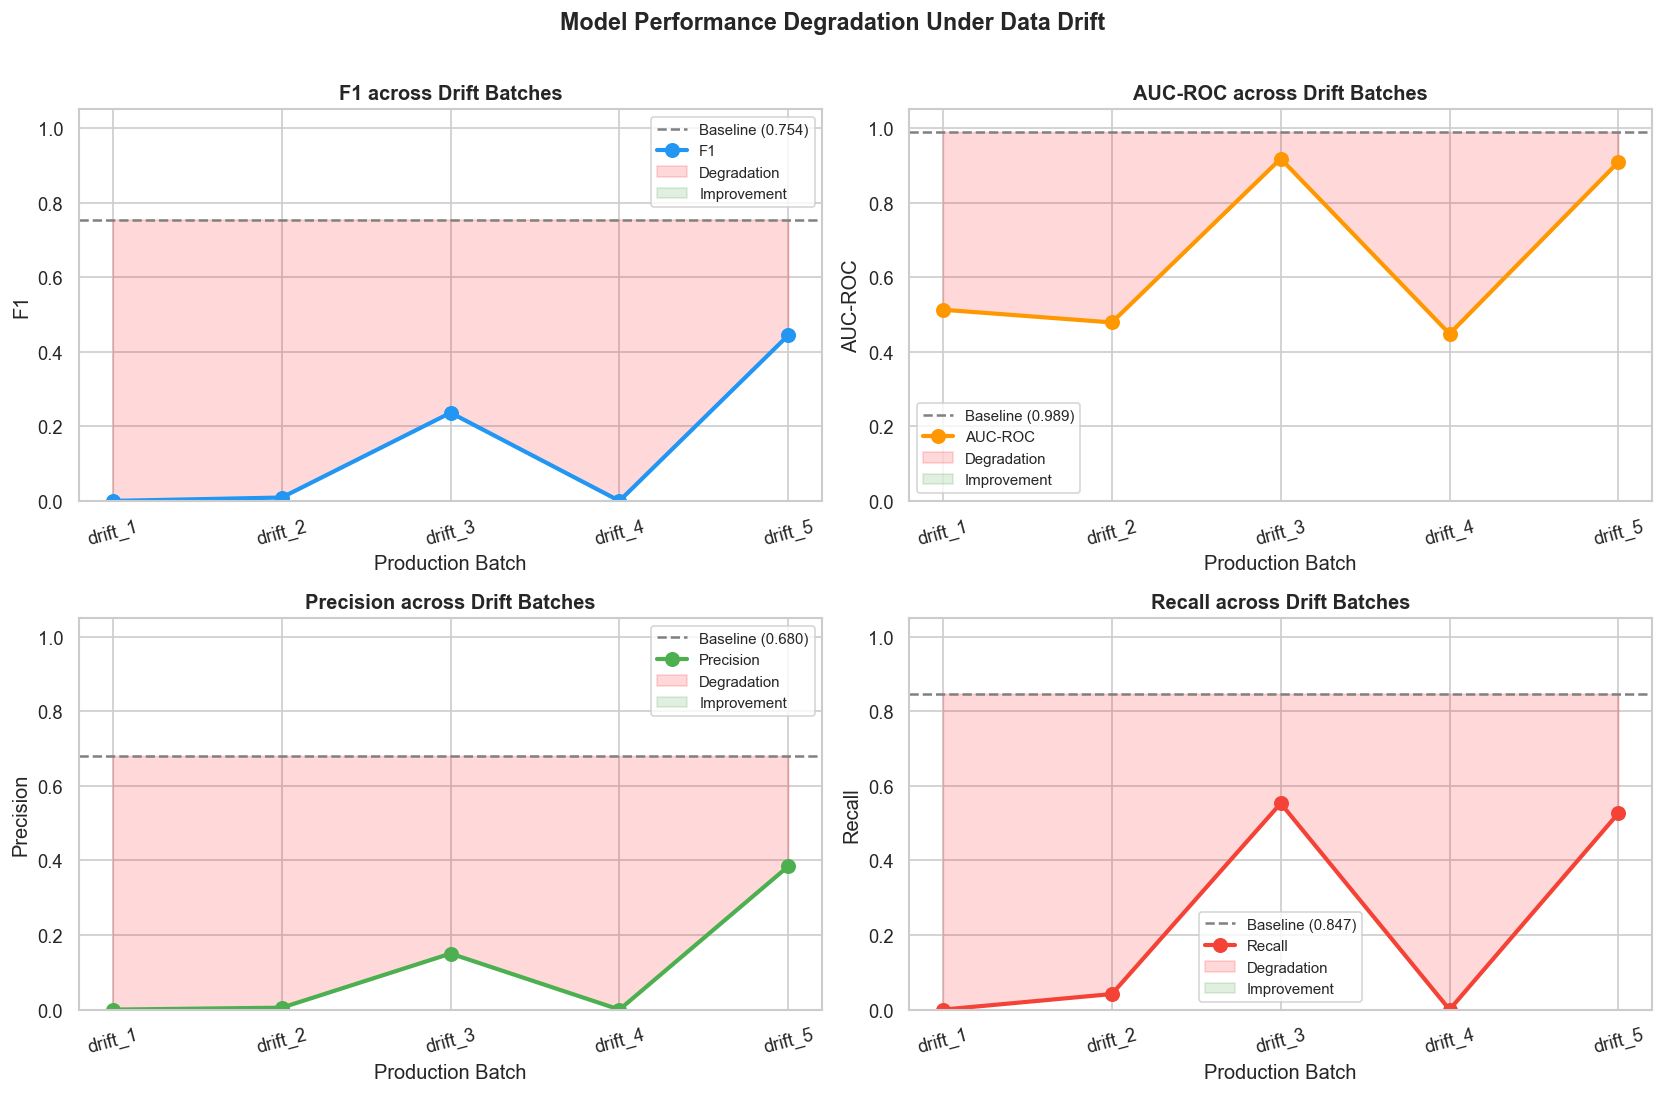

In [6]:
# Filter to drift batches only for the trend plot
drift_df = results_df.drop("BASELINE (test set)").reset_index()
batch_labels = drift_df["batch"].tolist()

baseline_vals = results_df.loc["BASELINE (test set)", ["F1", "AUC-ROC", "Precision", "Recall", "PR-AUC"]].to_dict()

metrics_to_plot = ["F1", "AUC-ROC", "Precision", "Recall"]
colors = ["#2196F3", "#FF9800", "#4CAF50", "#F44336"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    baseline_val = baseline_vals[metric]
    ax.axhline(baseline_val, color="gray", linestyle="--", linewidth=1.5,
               label=f"Baseline ({baseline_val:.3f})")

    vals = drift_df[metric].values
    ax.plot(batch_labels, vals, marker="o", color=color, linewidth=2.5,
            markersize=8, label=metric)

    ax.fill_between(batch_labels, vals, baseline_val,
                    where=(vals < baseline_val),
                    alpha=0.15, color="red", label="Degradation")
    ax.fill_between(batch_labels, vals, baseline_val,
                    where=(vals >= baseline_val),
                    alpha=0.12, color="green", label="Improvement")

    ax.set_title(f"{metric} across Drift Batches", fontweight="bold")
    ax.set_xlabel("Production Batch")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Model Performance Degradation Under Data Drift", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("impact_performance_trends.png", bbox_inches="tight")
plt.show()

## Fraud Rate vs. Performance  Connecting Drift to Degradation

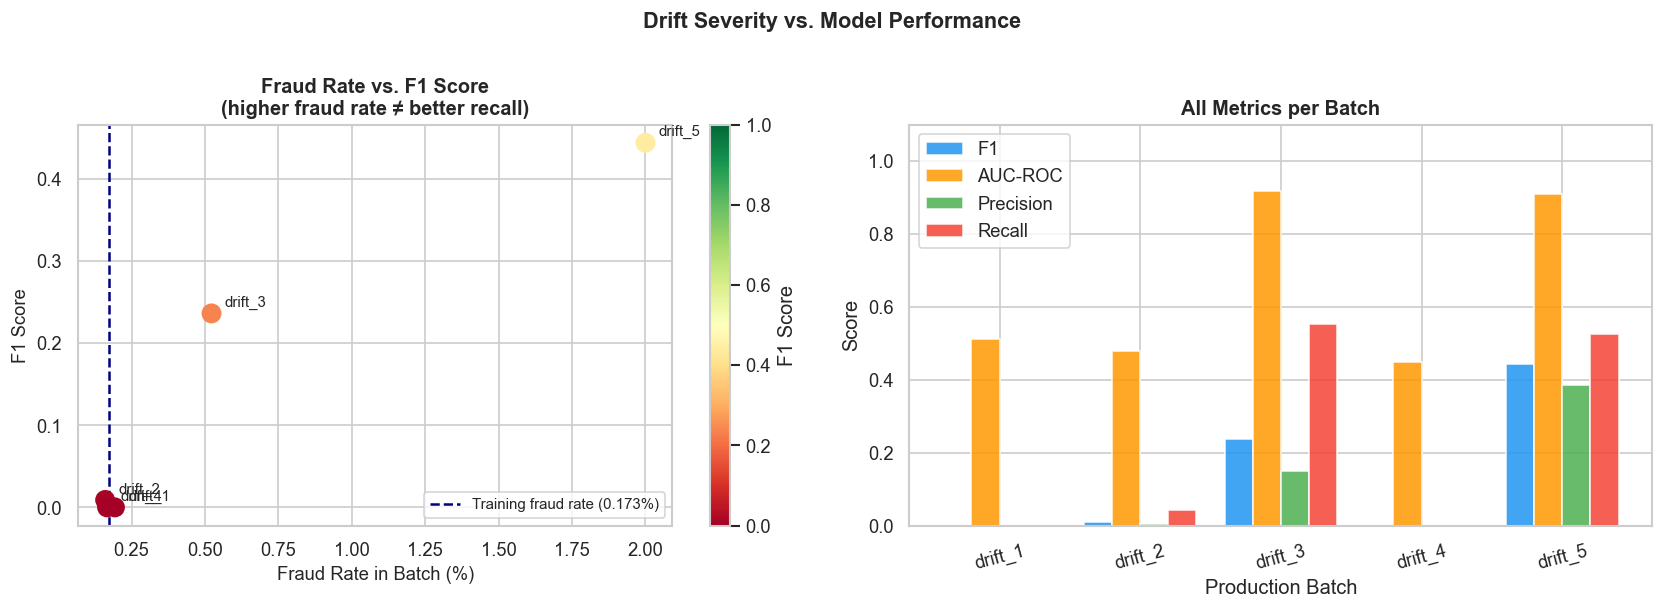

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Fraud Rate vs F1 scatter 
fraud_rates = drift_df["fraud_rate"].tolist()
f1_scores   = drift_df["F1"].values
batch_names = drift_df["batch"].values

ax = axes[0]
scatter = ax.scatter(fraud_rates, f1_scores, s=120, zorder=5,
                     c=f1_scores, cmap="RdYlGn", vmin=0, vmax=1)
for i, name in enumerate(batch_names):
    ax.annotate(name, (fraud_rates[i], f1_scores[i]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.axvline(0.173, color="navy", linestyle="--", linewidth=1.5,
           label="Training fraud rate (0.173%)")
ax.set_xlabel("Fraud Rate in Batch (%)", fontsize=11)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_title("Fraud Rate vs. F1 Score\n(higher fraud rate ≠ better recall)", fontweight="bold")
ax.legend(fontsize=9)
plt.colorbar(scatter, ax=ax, label="F1 Score")

# Right: All 4 metrics as grouped bar chart per batch 
ax2 = axes[1]
x = np.arange(len(batch_labels))
width = 0.2
metric_colors = {"F1": "#2196F3", "AUC-ROC": "#FF9800", "Precision": "#4CAF50", "Recall": "#F44336"}

for i, (metric, color) in enumerate(metric_colors.items()):
    vals = drift_df[metric].values
    bars = ax2.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.85)

ax2.set_xlabel("Production Batch")
ax2.set_ylabel("Score")
ax2.set_title("All Metrics per Batch", fontweight="bold")
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(batch_labels, rotation=15)
ax2.set_ylim(0, 1.1)
ax2.legend()

plt.suptitle("Drift Severity vs. Model Performance", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("impact_fraud_rate_vs_metrics.png", bbox_inches="tight")
plt.show()

## Confusion Matrices per Drift Batch

A confusion matrix shows the **raw error counts**:

|  | Predicted Legit | Predicted Fraud |
|--|-----------------|-----------------|
| **Actual Legit** | True Negative (TN)  | False Positive (FP) |
| **Actual Fraud** | False Negative (FN) | True Positive (TP)  |

- **False Negatives (FN)** = fraud we missed financial loss
- **False Positives (FP)** = legit flagged as fraud customer friction

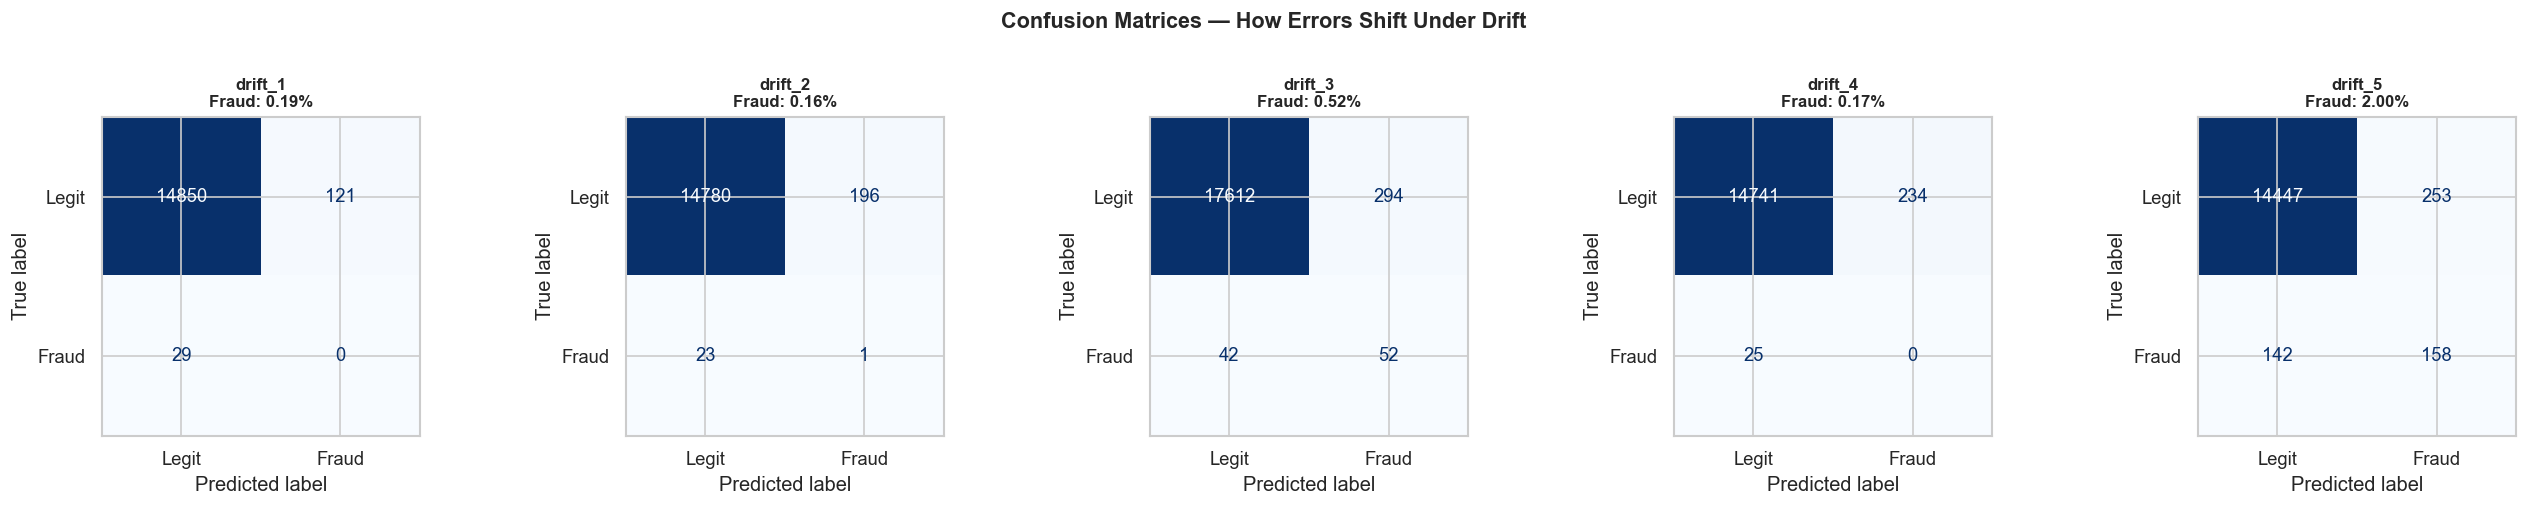

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, data) in zip(axes, batches.items()):
    y_pred = pipeline.predict(data["X"])
    cm = confusion_matrix(data["y"], y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Fraud"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    
    # Add fraud rate to title
    fraud_rate = data["fraud_rate"]
    ax.set_title(f"{name}\nFraud: {fraud_rate:.2f}%", fontweight="bold", fontsize=10)

plt.suptitle("Confusion Matrices — How Errors Shift Under Drift", 
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("impact_confusion_matrices.png", bbox_inches="tight")
plt.show()

## Quantified Performance Degradation Table

In [9]:
# Compute delta from baseline for each drift batch
baseline_vals = results_df.loc["BASELINE (test set)", ["F1", "AUC-ROC", "Precision", "Recall", "PR-AUC"]].to_dict()

degradation_rows = []
for _, row in drift_df.iterrows():
    delta_row = {"Batch": row["batch"], "Fraud Rate (%)": f"{row['fraud_rate']:.3f}%"}
    for metric in ["F1", "AUC-ROC", "Precision", "Recall", "PR-AUC"]:
        val   = row[metric]
        delta = val - baseline_vals[metric]
        delta_row[f"{metric} Score"] = f"{val:.4f}"
        delta_row[f"Δ {metric}"]     = f"{delta:+.4f}"
    degradation_rows.append(delta_row)

deg_df = pd.DataFrame(degradation_rows)

# Pretty print
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
display(deg_df)

,Batch,Fraud Rate (%),F1 Score,Δ F1,AUC-ROC Score,Δ AUC-ROC,Precision Score,Δ Precision,Recall Score,Δ Recall,PR-AUC Score,Δ PR-AUC
0,drift_1,0.193%,0.0000,-0.7545,0.5127,-0.4767,0.0000,-0.6803,0.0000,-0.8469,0.0020,-0.8633
1,drift_2,0.160%,0.0090,-0.7455,0.4786,-0.5108,0.0051,-0.6752,0.0417,-0.8052,0.0017,-0.8636
2,drift_3,0.522%,0.2364,-0.5181,0.9179,-0.0715,0.1503,-0.5300,0.5532,-0.2937,0.4195,-0.4458
3,drift_4,0.167%,0.0000,-0.7545,0.4480,-0.5414,0.0000,-0.6803,0.0000,-0.8469,0.0014,-0.8639
4,drift_5,2.000%,0.4444,-0.3101,0.9089,-0.0805,0.3844,-0.2959,0.5267,-0.3202,0.4620,-0.4033


## Degradation Heatmap

A heatmap gives an at-a-glance view of which batch × metric combination suffers the most.

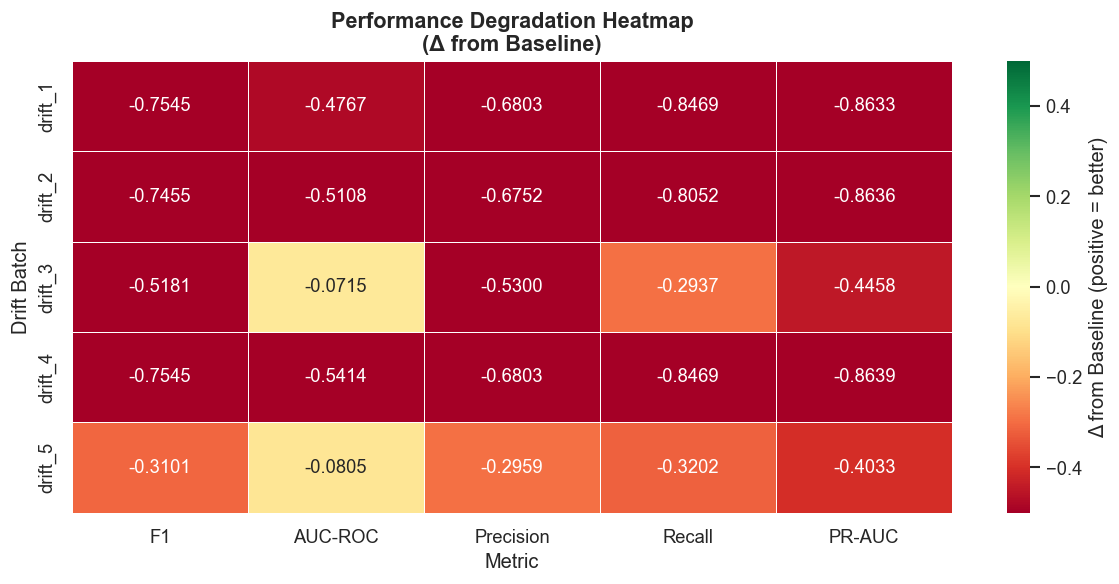

In [10]:
# Build numeric delta matrix
metrics_list = ["F1", "AUC-ROC", "Precision", "Recall", "PR-AUC"]
delta_matrix = np.zeros((len(batch_labels), len(metrics_list)))

for i, name in enumerate(batch_labels):
    row = drift_df[drift_df["batch"] == name].iloc[0]
    for j, metric in enumerate(metrics_list):
        delta_matrix[i, j] = row[metric] - baseline_vals[metric]

delta_plot_df = pd.DataFrame(delta_matrix, index=batch_labels, columns=metrics_list)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    delta_plot_df,
    annot=True, fmt=".4f",
    cmap="RdYlGn", center=0,
    linewidths=0.5, ax=ax,
    vmin=-0.5, vmax=0.5,
    cbar_kws={"label": "Δ from Baseline (positive = better)"}
)
ax.set_title("Performance Degradation Heatmap\n(Δ from Baseline)", fontsize=13, fontweight="bold")
ax.set_xlabel("Metric")
ax.set_ylabel("Drift Batch")

plt.tight_layout()
plt.show()

## Drift Scores to Performance Drops

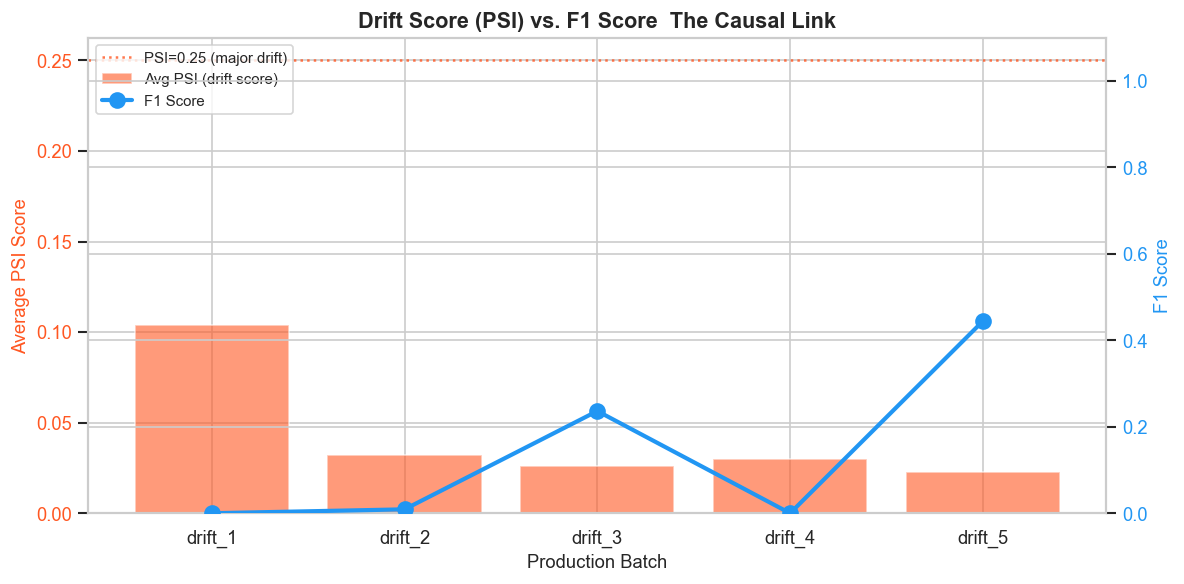

In [11]:
with open("drift_analysis.json") as f:
    _drift_data = json.load(f)
psi_scores = {k: v["avg_psi_v_features"] for k, v in _drift_data.items()}

f1_scores_dict = {row["batch"]: row["F1"] for _, row in drift_df.iterrows()}

fig, ax1 = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(batch_labels))
psi_vals = [psi_scores[b] for b in batch_labels]
f1_vals  = [f1_scores_dict[b] for b in batch_labels]

color_psi = "#FF5722"
color_f1  = "#2196F3"

# PSI bars
bars = ax1.bar(x_pos, psi_vals, color=color_psi, alpha=0.6, label="Avg PSI (drift score)")
ax1.set_xlabel("Production Batch", fontsize=11)
ax1.set_ylabel("Average PSI Score", color=color_psi, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_psi)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(batch_labels)
ax1.axhline(0.25, color=color_psi, linestyle=":", linewidth=1.5, alpha=0.8, label="PSI=0.25 (major drift)")

# F1 line on secondary axis
ax2 = ax1.twinx()
ax2.plot(x_pos, f1_vals, marker="o", color=color_f1, linewidth=2.5,
         markersize=9, label="F1 Score", zorder=5)
ax2.set_ylabel("F1 Score", color=color_f1, fontsize=11)
ax2.tick_params(axis="y", labelcolor=color_f1)
ax2.set_ylim(0, 1.1)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.title("Drift Score (PSI) vs. F1 Score  The Causal Link", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:

import json
import numpy as np

production_results = {}

for name, data in batches.items():
    y_pred_d = pipeline.predict(data["X"])
    y_prob_d = pipeline.predict_proba(data["X"])[:, 1]

    cm = confusion_matrix(data["y"], y_pred_d)

    production_results[name] = {
        "F1":               round(float(f1_score(data["y"], y_pred_d, zero_division=0)), 4),
        "AUC-ROC":          round(float(roc_auc_score(data["y"], y_prob_d)), 4),
        "Precision":        round(float(precision_score(data["y"], y_pred_d, zero_division=0)), 4),
        "Recall":           round(float(recall_score(data["y"], y_pred_d, zero_division=0)), 4),
        "PR-AUC":           round(float(auc(*precision_recall_curve(data["y"], y_prob_d)[:2][::-1])), 4),
        "fraud_rate":       round(float(data["y"].mean() * 100), 4),
        "confusion_matrix": cm.tolist(),
    }


with open("production_results.json", "w") as f:
    json.dump(production_results, f, indent=2)

print("Saved: production_results.json")

Saved: production_results.json


Final Summary & MLOps Recommendations
Key takeaways
Fraud rate change = concept drift. The model was calibrated for 0.173% fraud.
When the real rate rises to 2%, the model's probability estimates are wrong.
It underestimates fraud probability, causing misses.

AUC-ROC is more robust than F1. It doesn't depend on the classification threshold,
so small distribution shifts don't tank it. F1 is more sensitive because it uses hard predictions.

Precision and Recall move in opposite directions as fraud rate increases.
High fraud rate → more fraud in the dataset → recall can appear to improve artificially
while precision drops (more false positives flood the positive pool).

Covariate drift is sneaky. drift_4 looks stable by fraud rate, but PSI on
key features may signal a shift. This is why you need both performance monitoring
AND feature distribution monitoring.